# Notebook 04: Baseline Risk Modeling

This notebook builds baseline classification models for 30-day readmission risk.

The goals are:

- load the model-ready dataset from Notebook 03
- define model features and target
- create a patient-aware train/test split
- build preprocessing pipelines
- train baseline models
- evaluate model performance beyond accuracy
- export baseline model results

This notebook does not perform threshold strategy or outreach prioritization yet.

## 1. Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_validate
from sklearn.metrics import make_scorer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

## 2. Project Paths

In [2]:
def find_project_root(start_path=None):
    """
    Finds the project root by walking upward until the cleaned dataset path is found.
    This avoids relying on the current working directory being exactly the project root
    or the notebooks folder.
    """
    start_path = Path.cwd() if start_path is None else Path(start_path)

    for path in [start_path, *start_path.parents]:
        expected_file = path / "data" / "processed" / "diabetes_readmission_cleaned.csv"
        if expected_file.exists():
            return path

    raise FileNotFoundError(
        "Could not locate project root. Expected to find "
        "'data/processed/diabetes_readmission_cleaned.csv' in this folder or a parent folder."
    )


PROJECT_ROOT = find_project_root()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS = PROJECT_ROOT / "outputs"
MODEL_RESULTS = OUTPUTS / "model_results"
FIGURES = OUTPUTS / "figures"

for path in [DATA_PROCESSED, OUTPUTS, MODEL_RESULTS, FIGURES]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root detected successfully.")
print("Project folder:", PROJECT_ROOT.name)

Project root detected successfully.
Project folder: 03_risk_stratification_intervention_prioritization


## 3. Load Model-Ready Data

In [3]:
model_ready_path = DATA_PROCESSED / "diabetes_readmission_model_ready.csv"
feature_list_path = MODEL_RESULTS / "feature_list.csv"

assert model_ready_path.exists(), f"Missing model-ready dataset: {model_ready_path}"
assert feature_list_path.exists(), f"Missing feature list: {feature_list_path}"

df_model = pd.read_csv(model_ready_path)
feature_metadata = pd.read_csv(feature_list_path)

print("Model-ready dataset shape:", df_model.shape)
print("Feature metadata shape:", feature_metadata.shape)

display(df_model.head())
display(feature_metadata.head())

Model-ready dataset shape: (101766, 44)
Feature metadata shape: (38, 3)


,encounter_id,patient_nbr,readmitted_30d,race,gender,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_midpoint,age_order,total_prior_visits,medication_change_count,A1Cresult_tested_flag,max_glu_serum_tested_flag,prior_outpatient_flag,prior_emergency_flag,prior_inpatient_flag,high_prior_utilization_flag,long_stay_flag,any_medication_change_flag,insulin_flag,diabetes_med_flag,diabetes_med_changed_flag,time_in_hospital_group,total_prior_visits_group,diagnosis_count_group,medication_count_group,admission_type_id_cat,discharge_disposition_id_cat,admission_source_id_cat,diag_1_category,diag_2_category,diag_3_category,medical_specialty_grouped,race_missing_flag,payer_code_missing_flag,medical_specialty_missing_flag,weight_missing_flag
0,2278392,8222157,0,Caucasian,Female,[0-10),1,41,0,1,0,0,0,1,5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1-2 days,0,1-3,1-10,6,25,1,Diabetes,Missing,Missing,Rare,0,1,0,1
1,149190,55629189,0,Caucasian,Female,[10-20),3,59,0,18,0,0,0,9,15,2,0,1,0,0,0,0,0,0,0,1,1,1,1,3-4 days,0,7-9,11-20,1,1,7,Other,Diabetes,Other,Missing,0,1,1,1
2,64410,86047875,0,AfricanAmerican,Female,[20-30),2,11,5,13,2,0,1,6,25,3,3,0,0,0,1,0,1,0,0,0,0,1,0,1-2 days,2-3,4-6,11-20,1,1,7,Other,Diabetes,Supplementary_V,Missing,0,1,1,1
3,500364,82442376,0,Caucasian,Male,[30-40),2,44,1,16,0,0,0,7,35,4,0,1,0,0,0,0,0,0,0,1,1,1,1,1-2 days,0,7-9,11-20,1,1,7,Other,Diabetes,Circulatory,Missing,0,1,1,1
4,16680,42519267,0,Caucasian,Male,[40-50),1,51,0,8,0,0,0,5,45,5,0,0,0,0,0,0,0,0,0,0,1,1,1,1-2 days,0,4-6,1-10,1,1,7,Neoplasms,Neoplasms,Diabetes,Missing,0,1,1,1


,feature,feature_type,included_in_primary_model
0,time_in_hospital,numeric,True
1,num_lab_procedures,numeric,True
2,num_procedures,numeric,True
3,num_medications,numeric,True
4,number_outpatient,numeric,True


In [4]:
required_columns = [
    "encounter_id",
    "patient_nbr",
    "readmitted_30d"
]

missing_required = [col for col in required_columns if col not in df_model.columns]
assert len(missing_required) == 0, f"Missing required columns: {missing_required}"

assert set(df_model["readmitted_30d"].dropna().unique()) <= {0, 1}, "Target must be binary."

print("Required columns found.")
print(f"Rows: {len(df_model):,}")
print(f"Unique patients: {df_model['patient_nbr'].nunique():,}")
print(f"Baseline 30-day readmission rate: {df_model['readmitted_30d'].mean():.2%}")

Required columns found.
Rows: 101,766
Unique patients: 71,518
Baseline 30-day readmission rate: 11.16%


### Interpretation

The model-ready dataset loaded successfully.

`encounter_id` and `patient_nbr` are retained for tracking and patient-aware splitting.

They should not be used as predictive features.

## 4. Define Features and Target

In [5]:
target_col = "readmitted_30d"
group_col = "patient_nbr"

feature_cols = feature_metadata["feature"].tolist()

# Keep only features that exist in the model-ready dataset.
feature_cols = [col for col in feature_cols if col in df_model.columns]

forbidden_features = ["encounter_id", "patient_nbr", "readmitted", "readmitted_30d"]

for col in forbidden_features:
    assert col not in feature_cols, f"Forbidden feature found in feature list: {col}"

X = df_model[feature_cols].copy()
y = df_model[target_col].copy()
groups = df_model[group_col].copy()

print("Total features:", len(feature_cols))
print("Target:", target_col)
print("Group column:", group_col)

Total features: 38
Target: readmitted_30d
Group column: patient_nbr


In [6]:
numeric_features = feature_metadata.loc[
    feature_metadata["feature_type"].isin(["numeric", "binary", "missing_indicator"]),
    "feature"
].tolist()

categorical_features = feature_metadata.loc[
    feature_metadata["feature_type"].eq("categorical"),
    "feature"
].tolist()

numeric_features = [col for col in numeric_features if col in X.columns]
categorical_features = [col for col in categorical_features if col in X.columns]

feature_type_summary = pd.DataFrame({
    "feature_type": ["numeric_binary_missing_indicator", "categorical", "total"],
    "feature_count": [
        len(numeric_features),
        len(categorical_features),
        len(numeric_features) + len(categorical_features)
    ]
})

display(feature_type_summary)

,feature_type,feature_count
0,numeric_binary_missing_indicator,27
1,categorical,11
2,total,38


In [7]:
display(feature_metadata.sort_values(["feature_type", "feature"]))

,feature,feature_type,included_in_primary_model
12,A1Cresult_tested_flag,binary,True
19,any_medication_change_flag,binary,True
22,diabetes_med_changed_flag,binary,True
21,diabetes_med_flag,binary,True
17,high_prior_utilization_flag,binary,True
20,insulin_flag,binary,True
18,long_stay_flag,binary,True
13,max_glu_serum_tested_flag,binary,True
15,prior_emergency_flag,binary,True
16,prior_inpatient_flag,binary,True


### Interpretation

The predictive feature set is loaded from the feature list created in Notebook 03.

Identifiers, target-derived columns, and tracking fields are excluded from the model feature matrix.

Numeric, binary, and missingness-indicator features will be processed as numeric variables.

Categorical features will be imputed and one-hot encoded inside the modeling pipeline.

## 5. Patient-Aware Train/Test Split

In [8]:
# GroupShuffleSplit keeps all encounters from the same patient either in train or test.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(splitter.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (81613, 38)
Test shape: (20153, 38)


In [9]:
train_patients = set(groups_train)
test_patients = set(groups_test)

patient_overlap = train_patients.intersection(test_patients)

assert len(patient_overlap) == 0, "Patient leakage found: some patients appear in both train and test."

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "encounter_count": [len(X_train), len(X_test)],
    "unique_patient_count": [groups_train.nunique(), groups_test.nunique()],
    "readmission_count": [int(y_train.sum()), int(y_test.sum())],
    "readmission_rate": [y_train.mean(), y_test.mean()]
})

display(split_summary)

print("Patient overlap between train and test:", len(patient_overlap))

,split,encounter_count,unique_patient_count,readmission_count,readmission_rate
0,train,81613,57214,9206,0.112801
1,test,20153,14304,2151,0.106733


Patient overlap between train and test: 0


### Interpretation

The train/test split is patient-aware.

This avoids the random row-level split problem where encounters from the same patient could appear in both training and testing data.

Because `GroupShuffleSplit` groups by patient, it does not perfectly stratify the target. Therefore, the train and test readmission rates should be compared after splitting.

Because the split is patient-aware, the train/test class balance may not match perfectly. This is acceptable here because preventing patient overlap is more important than exact row-level stratification.

## 6. Build Preprocessing Pipeline

In [10]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created.")

Preprocessor created.


### Interpretation

The preprocessing pipeline handles missing values and categorical encoding inside the model pipeline.

This is important because preprocessing should be learned from the training data only, then applied to the test data.

Doing imputation or encoding before the split could leak information from the test set into training.

## 7. Define Baseline Models

In [11]:
dummy_model = DummyClassifier(
    strategy="most_frequent"
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42
        ))
    ]
)

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=100,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

models = {
    "Dummy Classifier": dummy_model,
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model
}

print("Models defined:", list(models.keys()))

Models defined: ['Dummy Classifier', 'Logistic Regression', 'Decision Tree']


### Interpretation

The Dummy Classifier is included as a sanity-check baseline.

It helps show why accuracy can be misleading when the positive class is uncommon.

Logistic Regression is useful because it is interpretable.

Decision Tree is useful because it can capture nonlinear splits, but it can overfit if not constrained.

`class_weight="balanced"` is used for Logistic Regression and Decision Tree to compensate for the low positive-class rate. This increases attention to the readmission class, but the default 0.50 decision threshold is still provisional. Later notebooks should evaluate thresholds based on outreach capacity rather than treating 0.50 as the final operational cutoff.

## 8. Evaluation Helper Function

In [12]:
def evaluate_classifier(model_name, fitted_model, X_test, y_test):
    """
    Evaluates a fitted binary classification model.

    Uses both threshold-based metrics and probability-based metrics.
    Accuracy is included, but it should not be the main decision metric for this imbalanced target.
    """
    y_pred = fitted_model.predict(X_test)

    if hasattr(fitted_model, "predict_proba"):
        y_score = fitted_model.predict_proba(X_test)[:, 1]
    else:
        y_score = y_pred

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score),
        "pr_auc": average_precision_score(y_test, y_score)
    }

    confusion = confusion_matrix(y_test, y_pred)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    return metrics, confusion, report, y_score

### Interpretation

Metrics are split into two types:

Threshold-based metrics:

- accuracy
- precision
- recall
- F1
- confusion matrix

Probability-ranking metrics:

- ROC AUC
- PR AUC

For this project, PR AUC and recall are especially important because the positive class is relatively uncommon.

## 9. Train and Evaluate Baseline Models

In [13]:
model_metrics = []
confusion_matrices = {}
classification_reports = {}
prediction_scores = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    model.fit(X_train, y_train)

    metrics, confusion, report, y_score = evaluate_classifier(
        model_name=model_name,
        fitted_model=model,
        X_test=X_test,
        y_test=y_test
    )

    model_metrics.append(metrics)
    confusion_matrices[model_name] = confusion
    classification_reports[model_name] = report
    prediction_scores[model_name] = y_score

    print(f"{model_name} complete.")

Training Dummy Classifier...
Dummy Classifier complete.
Training Logistic Regression...
Logistic Regression complete.
Training Decision Tree...
Decision Tree complete.


In [14]:
baseline_metrics = pd.DataFrame(model_metrics)

metric_cols = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc"
]

baseline_metrics_display = baseline_metrics.copy()
baseline_metrics_display[metric_cols] = baseline_metrics_display[metric_cols].round(4)

display(baseline_metrics_display.sort_values("pr_auc", ascending=False))

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Logistic Regression,0.6677,0.1752,0.5700,0.2680,0.6694,0.2059
2,Decision Tree,0.6899,0.1718,0.4988,0.2556,0.6497,0.1824
0,Dummy Classifier,0.8933,0.0000,0.0000,0.0000,0.5000,0.1067


### Interpretation

Accuracy should not be treated as the main success metric.

A model can achieve high accuracy by mostly predicting the majority class, but that would be operationally useless for identifying readmission risk.

For this project, stronger baseline performance means:

- better PR AUC
- useful recall
- acceptable precision
- better ranking of high-risk encounters

## 10. Confusion Matrices

In [15]:
for model_name, matrix in confusion_matrices.items():
    confusion_df = pd.DataFrame(
        matrix,
        index=["Actual 0", "Actual 1"],
        columns=["Predicted 0", "Predicted 1"]
    )

    print(f"\n{model_name}")
    display(confusion_df)


Dummy Classifier


,Predicted 0,Predicted 1
Actual 0,18002,0
Actual 1,2151,0



Logistic Regression


,Predicted 0,Predicted 1
Actual 0,12231,5771
Actual 1,925,1226



Decision Tree


,Predicted 0,Predicted 1
Actual 0,12830,5172
Actual 1,1078,1073


### Interpretation

The confusion matrix shows the tradeoff between false positives and false negatives.

For readmission risk modeling:

- false negatives are patients who were readmitted but were not flagged
- false positives are patients flagged as high risk but not readmitted

In a care management context, false negatives may be more concerning because missed high-risk patients may not receive outreach.

## 11. Classification Reports

In [16]:
classification_report_tables = []

for model_name, report in classification_reports.items():
    report_df = pd.DataFrame(report).T.reset_index()
    report_df = report_df.rename(columns={"index": "class_or_metric"})
    report_df.insert(0, "model", model_name)

    classification_report_tables.append(report_df)

classification_report_df = pd.concat(classification_report_tables, ignore_index=True)

display(classification_report_df)

,model,class_or_metric,precision,recall,f1-score,support
0,Dummy Classifier,0,0.893267,1.000000,0.943625,18002.000000
1,Dummy Classifier,1,0.000000,0.000000,0.000000,2151.000000
2,Dummy Classifier,accuracy,0.893267,0.893267,0.893267,0.893267
3,Dummy Classifier,macro avg,0.446633,0.500000,0.471812,20153.000000
4,Dummy Classifier,weighted avg,0.797925,0.893267,0.842908,20153.000000
5,Logistic Regression,0,0.929690,0.679425,0.785095,18002.000000
6,Logistic Regression,1,0.175218,0.569967,0.268037,2151.000000
7,Logistic Regression,accuracy,0.667742,0.667742,0.667742,0.667742
8,Logistic Regression,macro avg,0.552454,0.624696,0.526566,20153.000000
9,Logistic Regression,weighted avg,0.849162,0.667742,0.729908,20153.000000


### Interpretation

The class-level report is especially useful for reviewing performance on class `1`, which represents 30-day readmission.

The positive class is the operationally important class for outreach prioritization.

## 12. ROC Curve

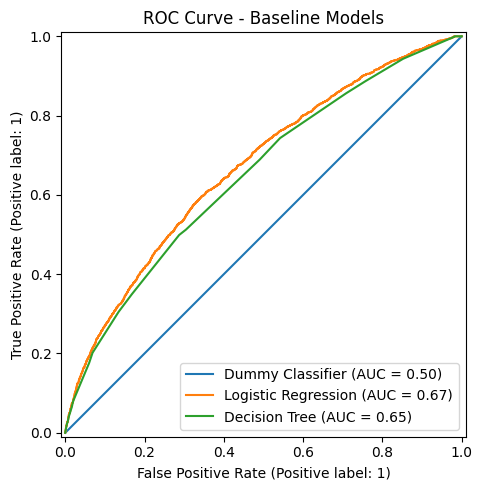

In [17]:
plt.figure(figsize=(7, 5))

for model_name, y_score in prediction_scores.items():
    RocCurveDisplay.from_predictions(
        y_test,
        y_score,
        name=model_name,
        ax=plt.gca()
    )

plt.title("ROC Curve - Baseline Models")
plt.tight_layout()

plt.savefig(FIGURES / "baseline_models_roc_curve.png", dpi=300)
plt.show()

### Interpretation

ROC AUC measures how well the model ranks positive cases above negative cases across thresholds.

However, ROC AUC can look overly optimistic when the positive class is uncommon.

For this project, PR AUC is usually more informative than ROC AUC.

## 13. Precision-Recall Curve

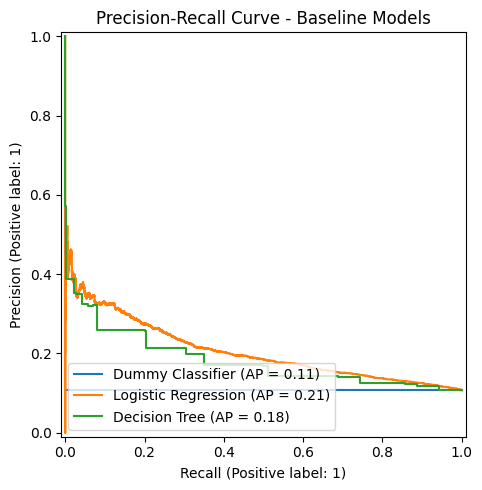

In [18]:
plt.figure(figsize=(7, 5))

for model_name, y_score in prediction_scores.items():
    PrecisionRecallDisplay.from_predictions(
        y_test,
        y_score,
        name=model_name,
        ax=plt.gca()
    )

plt.title("Precision-Recall Curve - Baseline Models")
plt.tight_layout()

plt.savefig(FIGURES / "baseline_models_precision_recall_curve.png", dpi=300)
plt.show()

### Interpretation

The precision-recall curve focuses on positive-class performance.

This is important because the project goal is not just to classify all encounters correctly.

The goal is to rank and identify encounters with higher readmission risk for possible outreach.

## 14. Select Baseline Model

In [19]:
selected_baseline_model_name = (
    baseline_metrics
    .sort_values(["pr_auc", "roc_auc"], ascending=False)
    .iloc[0]["model"]
)

selected_baseline_metrics = baseline_metrics[
    baseline_metrics["model"] == selected_baseline_model_name
].copy()

print("Selected baseline model:", selected_baseline_model_name)
display(selected_baseline_metrics)

Selected baseline model: Logistic Regression


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Logistic Regression,0.667742,0.175218,0.569967,0.268037,0.669442,0.205914


### Interpretation

The selected baseline model is chosen primarily using PR AUC, with ROC AUC as a secondary ranking metric.

This selection is provisional.

Notebook 05 will compare stronger models and focus more directly on top-risk capture and threshold strategy.

## 15. Cross-Validation Robustness Check

In [20]:
# StratifiedGroupKFold tries to preserve the target rate across folds
# while keeping all encounters from the same patient in the same fold.
cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_fold_summary = []

for fold, (cv_train_idx, cv_valid_idx) in enumerate(
    cv.split(X_train, y_train, groups=groups_train),
    start=1
):
    fold_train_groups = set(groups_train.iloc[cv_train_idx])
    fold_valid_groups = set(groups_train.iloc[cv_valid_idx])
    group_overlap = fold_train_groups.intersection(fold_valid_groups)

    cv_fold_summary.append({
        "fold": fold,
        "train_encounters": len(cv_train_idx),
        "valid_encounters": len(cv_valid_idx),
        "train_patients": len(fold_train_groups),
        "valid_patients": len(fold_valid_groups),
        "patient_overlap": len(group_overlap),
        "train_readmission_rate": y_train.iloc[cv_train_idx].mean(),
        "valid_readmission_rate": y_train.iloc[cv_valid_idx].mean()
    })

cv_fold_summary = pd.DataFrame(cv_fold_summary)

display(cv_fold_summary)

,fold,train_encounters,valid_encounters,train_patients,valid_patients,patient_overlap,train_readmission_rate,valid_readmission_rate
0,1,65290,16323,45775,11439,0,0.112804,0.112786
1,2,65289,16324,45806,11408,0,0.112806,0.112779
2,3,65291,16322,45783,11431,0,0.112803,0.112793
3,4,65288,16325,45753,11461,0,0.112793,0.112833
4,5,65294,16319,45739,11475,0,0.112798,0.112813


### Interpretation

This cross-validation check confirms whether model performance is stable across multiple patient-aware folds.

Each fold keeps patients non-overlapping between training and validation.

The validation readmission rates should be reviewed because perfect stratification is not always possible when group constraints are applied.

## 16. Cross-validation scoring 

In [21]:
cv_scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

In [22]:
cv_results = []

for model_name, model in models.items():
    print(f"Cross-validating {model_name}...")

    scores = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        groups=groups_train,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=-1,
        return_train_score=False
    )

    row = {"model": model_name}

    for metric_name in cv_scoring.keys():
        test_metric = f"test_{metric_name}"
        row[f"{metric_name}_mean"] = scores[test_metric].mean()
        row[f"{metric_name}_std"] = scores[test_metric].std()

    cv_results.append(row)

cv_results = pd.DataFrame(cv_results)

display(
    cv_results
    .sort_values("pr_auc_mean", ascending=False)
    .round(4)
)

Cross-validating Dummy Classifier...
Cross-validating Logistic Regression...
Cross-validating Decision Tree...


,model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std
1,Logistic Regression,0.6624,0.0046,0.1824,0.0014,0.5719,0.0105,0.2765,0.0021,0.6724,0.0046,0.2155,0.0064
2,Decision Tree,0.6394,0.0342,0.1719,0.0067,0.5716,0.0469,0.2637,0.0033,0.6558,0.0041,0.1962,0.0053
0,Dummy Classifier,0.8872,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5000,0.0000,0.1128,0.0000


### Interpretation

Cross-validation provides a more stable estimate than a single split.

The holdout test set is still useful, but cross-validation helps show whether model ranking is consistent across patient-aware folds.

For this project, PR AUC and recall remain more important than accuracy.

## 17. Export Outputs

In [ ]:
baseline_metrics_output_path = MODEL_RESULTS / "baseline_model_metrics.csv"
classification_report_output_path = MODEL_RESULTS / "baseline_classification_reports.csv"
split_summary_output_path = MODEL_RESULTS / "patient_aware_split_summary.csv"
selected_baseline_output_path = MODEL_RESULTS / "selected_baseline_model.csv"

baseline_metrics.to_csv(baseline_metrics_output_path, index=False)
classification_report_df.to_csv(classification_report_output_path, index=False)
split_summary.to_csv(split_summary_output_path, index=False)
selected_baseline_metrics.to_csv(selected_baseline_output_path, index=False)

cv_fold_summary_output_path = MODEL_RESULTS / "baseline_cv_fold_summary.csv"
cv_results_output_path = MODEL_RESULTS / "baseline_cv_results.csv"

cv_fold_summary.to_csv(cv_fold_summary_output_path, index=False)
cv_results.to_csv(cv_results_output_path, index=False)

print("Saved CV fold summary to", cv_fold_summary_output_path.relative_to(PROJECT_ROOT))
print("Saved CV results to:", cv_results_output_path.relative_to(PROJECT_ROOT))
print("Saved baseline metrics to:", baseline_metrics_output_path.relative_to(PROJECT_ROOT))
print("Saved classification reports to:", classification_report_output_path.relative_to(PROJECT_ROOT))
print("Saved split summary to:", split_summary_output_path.relative_to(PROJECT_ROOT))
print("Saved selected baseline model to:", selected_baseline_output_path.relative_to(PROJECT_ROOT))

Saved CV fold summary to outputs\model_results\baseline_cv_fold_summary.csv
Saved CV results to:` outputs\model_results\baseline_cv_results.csv
Saved baseline metrics to: outputs\model_results\baseline_model_metrics.csv
Saved classification reports to: outputs\model_results\baseline_classification_reports.csv
Saved split summary to: outputs\model_results\patient_aware_split_summary.csv
Saved selected baseline model to: outputs\model_results\selected_baseline_model.csv


## Notebook 04 Summary

This notebook built baseline models for 30-day readmission risk.

Main work completed:

- Loaded the model-ready dataset from Notebook 03
- Loaded the feature list
- Defined the target and feature matrix
- Used a patient-aware train/test split with `GroupShuffleSplit`
- Confirmed no patient overlap between train and test sets
- Built preprocessing pipelines for numeric and categorical features
- Trained a Dummy Classifier, Logistic Regression, and Decision Tree
- Evaluated models using accuracy, precision, recall, F1, ROC AUC, and PR AUC
- Reviewed confusion matrices and classification reports
- Plotted ROC and precision-recall curves
- Selected a provisional baseline model
- Added StratifiedGroupKFold cross-validation on the training set to assess robustness across patient-aware folds

Important modeling decision:

The model predicts encounter-level readmission risk, but train/test splitting is patient-aware using `patient_nbr`.

Next step:

Notebook 05 will compare stronger models and translate predicted probabilities into top-risk threshold and outreach-capacity strategy.